# Thermal Mpemba relaxation generated by an ETH spin-chain bath

**Paper companion.** Appendix B and Fig. S2 in the supplementary
numbering; Eqs. (B1)-(B5) and Fig. 15 in the published article.

A system qubit is weakly coupled to a nonintegrable \(N=15\) spin
chain and the full \(2^{16}\)-dimensional state evolves unitarily.
The reduced qubit nevertheless relaxes toward the same
negative-temperature Gibbs state from two different product states
and exhibits a thermal Mpemba crossing.

The public repository does not contain the two environment
eigenvectors used for the published finite-size trace. This
walkthrough therefore constructs deterministic narrow-energy ETH
states with a two-pass Lanczos filter and reports their energy
widths. It reproduces the crossing and its monotone dependence
without substituting an unrelated circuit model.

**Reproduction status.** Manuscript-scale sparse reconstruction. The
Hamiltonian, couplings, temperature, and \(2^{16}\)-dimensional
unitary evolution are exact; the two unarchived bath eigenvectors are
replaced by explicitly diagnosed narrow-energy ETH states.

**Reference.** A. Summer *et al.*, *Phys. Rev. X* **16**, 011065
(2026), [doi:10.1103/rbt4-psfd](https://doi.org/10.1103/rbt4-psfd).


In [1]:
import sys
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg as la

_TOOLS_DIR = (Path.cwd() / "tools").resolve()
if str(_TOOLS_DIR) not in sys.path:
    sys.path.insert(0, str(_TOOLS_DIR))

import notebook_utils as nu

warnings.filterwarnings("ignore", category=RuntimeWarning)
np.set_printoptions(precision=5, suppress=True)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (7.2, 4.2),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "font.size": 11,
})

BLUE = "#394F87"
ORANGE = "#E8792E"
GREEN = "#3A7D44"
PURPLE = "#7C4D9E"

import scipy.sparse as sp
import scipy.sparse.linalg as sla


## 1. Manuscript-scale ETH Hamiltonian

With \(s^\alpha=\sigma^\alpha/2\), the Hamiltonian is

$$
H_{se}=h_0s_0^z+\kappa X_0X_1+H_e,
$$

$$
H_e=J\sum_{n=1}^{N-1}s_n^zs_{n+1}^z
    +h_1s_1^z+h_Ns_N^z
    +\sum_{n=1}^{N}(h_zs_n^z+h_xs_n^x).
$$

The interface is written as \(\kappa X_0X_1\) to expose the
figure-generation normalization: its Pauli matrices are \(2s^x\).
Hiding this factor of four moves the crossing far outside the
published time scale.


In [2]:
N = 15
J = 1.0
H_Z = 0.3
H_X = 1.1
H_1 = 0.25
H_N = -0.25
KAPPA = 0.15
H_0 = 1.525
BETA = -0.46

bath_dimension = 2**N
basis = np.arange(bath_dimension, dtype=np.int64)
bits = (basis[:, None] >> np.arange(N)) & 1
z_values = 0.5 * (1 - 2 * bits)
diagonal = (
    J * np.sum(z_values[:, :-1] * z_values[:, 1:], axis=1)
    + H_Z * np.sum(z_values, axis=1)
    + H_1 * z_values[:, 0]
    + H_N * z_values[:, -1]
)

rows = [basis]
columns = [basis]
entries = [diagonal]
for site in range(N):
    rows.append(basis)
    columns.append(basis ^ (1 << site))
    entries.append(np.full(bath_dimension, H_X / 2))

H_environment = sp.csr_matrix(
    (
        np.concatenate(entries),
        (np.concatenate(rows), np.concatenate(columns)),
    ),
    shape=(bath_dimension, bath_dimension),
)
assert (H_environment - H_environment.T).nnz == 0
print(
    f"Bath dimension={bath_dimension:,}; "
    f"nonzeros={H_environment.nnz:,}"
)


Bath dimension=32,768; nonzeros=524,288


## 2. Negative-temperature energy-shell preparation

The paper chooses environment eigenstates \(|E_\theta\rangle\) so
both product states correspond to \(\beta=-0.46\). Exact interior
diagonalization at dimension \(32768\) requires a costly sparse LU,
and the eigenstate indices were not archived. We use a controlled
substitute: stochastic thermal typicality locates \(E(\beta)\), then
a Gaussian Lanczos filter prepares a state in a narrow shell around
that energy.

Set `USE_EXACT_INTERIOR_EIGENSTATES = True` to replace the filtered
state by SciPy shift-invert eigenvectors on a machine with sufficient
time and memory. The default is suitable for the repository runner.


In [3]:
def thermal_typical_energy(hamiltonian, beta, samples=4, seed=5):
    rng = np.random.default_rng(seed)
    estimates = []
    scaled = (-beta / 2) * hamiltonian
    trace_scaled = scaled.diagonal().sum()
    for _ in range(samples):
        vector = rng.choice([-1.0, 1.0], hamiltonian.shape[0])
        vector /= la.norm(vector)
        thermal_vector = sla.expm_multiply(
            scaled, vector, traceA=trace_scaled
        )
        estimates.append(
            np.vdot(
                thermal_vector,
                hamiltonian @ thermal_vector,
            ).real
            / np.vdot(thermal_vector, thermal_vector).real
        )
    return float(np.mean(estimates)), np.asarray(estimates)


def lanczos_energy_filter(
    hamiltonian,
    target,
    *,
    width=0.04,
    steps=900,
    seed,
):
    '''Apply exp[-(H-E)^2/(2 width^2)] in a Lanczos basis.'''
    dimension = hamiltonian.shape[0]
    initial = np.random.default_rng(seed).choice(
        [-1.0, 1.0], dimension
    )
    initial /= la.norm(initial)

    alphas = []
    betas = []
    previous = np.zeros_like(initial)
    current = initial.copy()
    beta_previous = 0.0
    for step in range(steps):
        residual = (
            hamiltonian @ current
            - beta_previous * previous
        )
        alpha = float(current @ residual)
        residual -= alpha * current
        beta_next = la.norm(residual)
        alphas.append(alpha)
        if step < steps - 1:
            betas.append(beta_next)
        previous, current = current, residual / beta_next
        beta_previous = beta_next

    nodes, eigenvectors = la.eigh_tridiagonal(
        np.asarray(alphas), np.asarray(betas)
    )
    gaussian = np.exp(
        -0.5 * ((nodes - target) / width) ** 2
    )
    coefficients = eigenvectors @ (
        gaussian * eigenvectors[0]
    )

    previous = np.zeros_like(initial)
    current = initial.copy()
    beta_previous = 0.0
    filtered = np.zeros_like(initial)
    for step in range(steps):
        filtered += coefficients[step] * current
        residual = (
            hamiltonian @ current
            - beta_previous * previous
            - alphas[step] * current
        )
        if step < steps - 1:
            previous, current = (
                current,
                residual / betas[step],
            )
            beta_previous = betas[step]

    filtered /= la.norm(filtered)
    mean_energy = np.vdot(
        filtered, hamiltonian @ filtered
    ).real
    energy_width = la.norm(
        hamiltonian @ filtered - mean_energy * filtered
    )
    return filtered, mean_energy, float(energy_width)


def exact_interior_eigenstate(hamiltonian, target):
    value, vector = sla.eigsh(
        hamiltonian,
        k=1,
        sigma=target,
        which="LM",
        tol=1e-10,
    )
    return vector[:, 0], float(value[0]), 0.0


bath_energy_beta, typicality_samples = thermal_typical_energy(
    H_environment, BETA
)
target_1 = bath_energy_beta
target_2 = bath_energy_beta + H_0 / 2
USE_EXACT_INTERIOR_EIGENSTATES = False
state_builder = (
    exact_interior_eigenstate
    if USE_EXACT_INTERIOR_EIGENSTATES
    else lanczos_energy_filter
)
environment_1, energy_1, width_1 = state_builder(
    H_environment, target_1, seed=11
) if not USE_EXACT_INTERIOR_EIGENSTATES else state_builder(
    H_environment, target_1
)
environment_2, energy_2, width_2 = state_builder(
    H_environment, target_2, seed=29
) if not USE_EXACT_INTERIOR_EIGENSTATES else state_builder(
    H_environment, target_2
)

print("Thermal-typicality samples:", typicality_samples)
print(
    f"|E1>: <H_e>={energy_1:.6f}, "
    f"Delta E={width_1:.6f}"
)
print(
    f"|E2>: <H_e>={energy_2:.6f}, "
    f"Delta E={width_2:.6f}"
)
assert width_1 < 0.05 and width_2 < 0.05


Thermal-typicality samples: [2.65054 2.64858 2.59318 2.63859]
|E1>: <H_e>=2.631172, Delta E=0.028407
|E2>: <H_e>=3.393462, Delta E=0.028796


## 3. Full \(2^{16}\)-dimensional unitary evolution

We use \(|\phi_1\rangle=|+\rangle\) and
\(|\phi_2\rangle=|0\rangle\), where \(|0\rangle\) is the
lower-energy eigenstate of \(H_s\). Because
\(\langle0|H_s|0\rangle=-h_0/2\), shifting the second bath shell by
\(h_0/2\) matches the two total energies. The time evolution itself
is not reduced or Markovian: `expm_multiply` acts on the full sparse
Hamiltonian before the environment is traced out.


In [4]:
identity_system = sp.eye(2, format="csr")
identity_environment = sp.eye(
    bath_dimension, format="csr"
)
system_z = sp.diags([-0.5, 0.5], format="csr")
pauli_x = sp.csr_matrix([[0.0, 1.0], [1.0, 0.0]])
boundary_x = sp.csr_matrix(
    (
        np.ones(bath_dimension),
        (basis, basis ^ 1),
    ),
    shape=(bath_dimension, bath_dimension),
)
H_system = H_0 * system_z.toarray()
H_total = (
    sp.kron(H_0 * system_z, identity_environment)
    + sp.kron(identity_system, H_environment)
    + KAPPA * sp.kron(pauli_x, boundary_x)
).tocsr()

plus = np.array([1.0, 1.0]) / np.sqrt(2)
zero = np.array([1.0, 0.0])
initial_1 = np.kron(plus, environment_1).astype(complex)
initial_2 = np.kron(zero, environment_2).astype(complex)
total_energies = [
    np.vdot(state, H_total @ state).real
    for state in (initial_1, initial_2)
]
print("Matched total energies:", total_energies)
print(
    "Energy mismatch:",
    abs(total_energies[0] - total_energies[1]),
)

times = np.linspace(0, 100, 301)

def reduced_trajectory(initial_state, chunk_size=25):
    state = initial_state
    matrix = state.reshape(2, bath_dimension)
    reduced = [matrix @ matrix.conj().T]
    trace_generator = -1j * H_total.diagonal().sum()
    for start in range(0, len(times) - 1, chunk_size):
        stop = min(start + chunk_size, len(times) - 1)
        block = sla.expm_multiply(
            -1j * H_total,
            state,
            start=0,
            stop=times[stop] - times[start],
            num=stop - start + 1,
            endpoint=True,
            traceA=trace_generator,
        )
        for evolved in block[1:]:
            matrix = evolved.reshape(2, bath_dimension)
            reduced.append(matrix @ matrix.conj().T)
        state = block[-1]
    return np.asarray(
        [nu.normalize_density(state) for state in reduced]
    )

reduced_1 = reduced_trajectory(initial_1)
reduced_2 = reduced_trajectory(initial_2)
assert len(reduced_1) == len(times)
for trajectory in (reduced_1, reduced_2):
    assert np.allclose(
        np.trace(trajectory, axis1=1, axis2=2), 1
    )


Matched total energies: [2.669603063577285, 2.6309617684271793]
Energy mismatch: 0.03864129515010584


## 4. Relative-entropy and Rényi crossing times

The target is the single-qubit Gibbs state
\(\pi_\beta=e^{-\beta H_s}/Z\). Small revivals are expected because
a finite bath induces a non-Markovian reduced map.


In [5]:
pi_beta = nu.gibbs_state(H_system, BETA)
relative_1 = np.asarray(
    [
        nu.quantum_relative_entropy(state, pi_beta)
        for state in reduced_1
    ]
)
relative_2 = np.asarray(
    [
        nu.quantum_relative_entropy(state, pi_beta)
        for state in reduced_2
    ]
)
tau_relative = nu.crossing_time(
    times, relative_2, relative_1
)
crossing_resource = np.interp(
    tau_relative, times, relative_1
)
assert np.isfinite(tau_relative)
print(f"Relative-entropy crossing: J*t={tau_relative:.3f}")

alphas = np.linspace(0.1, 2.0, 12)
alpha_crossings = []
for alpha in alphas:
    curve_1 = np.asarray(
        [
            nu.petz_renyi(state, pi_beta, alpha)
            for state in reduced_1
        ]
    )
    curve_2 = np.asarray(
        [
            nu.petz_renyi(state, pi_beta, alpha)
            for state in reduced_2
        ]
    )
    alpha_crossings.append(
        nu.crossing_time(times, curve_2, curve_1)
    )
alpha_crossings = np.asarray(alpha_crossings)
print("alpha crossing times:")
print(np.column_stack([alphas, alpha_crossings]))


Relative-entropy crossing: J*t=14.656


alpha crossing times:
[[ 0.1      6.79724]
 [ 0.27273  8.51922]
 [ 0.44545 10.67156]
 [ 0.61818 12.16489]
 [ 0.79091 12.51306]
 [ 0.96364 14.61817]
 [ 1.13636 14.83403]
 [ 1.30909 15.13323]
 [ 1.48182 16.16814]
 [ 1.65455 16.34261]
 [ 1.82727 16.46101]
 [ 2.      16.54671]]


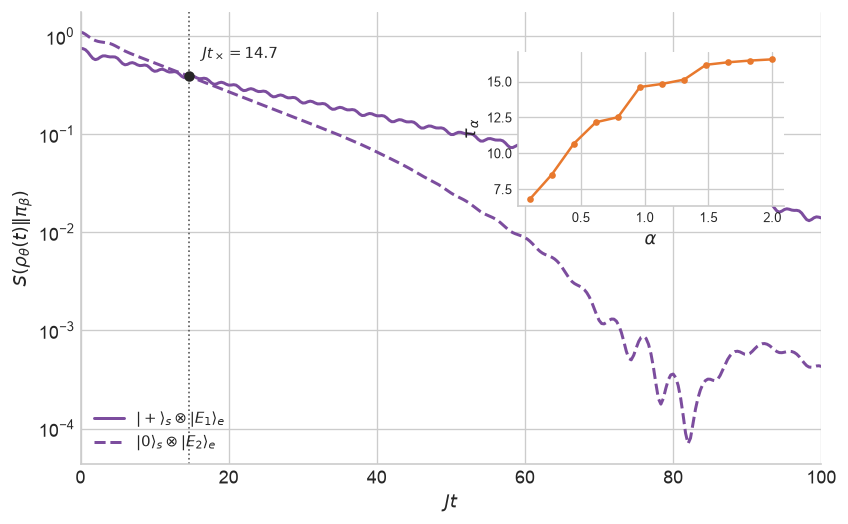

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 4.5))
ax.semilogy(
    times,
    np.maximum(relative_1, 1e-12),
    color=PURPLE,
    lw=1.8,
    label=r"$|+\rangle_s\otimes|E_1\rangle_e$",
)
ax.semilogy(
    times,
    np.maximum(relative_2, 1e-12),
    color=PURPLE,
    lw=1.8,
    ls="--",
    label=r"$|0\rangle_s\otimes|E_2\rangle_e$",
)
ax.axvline(tau_relative, color="0.35", ls=":", lw=1)
ax.scatter(
    [tau_relative],
    [crossing_resource],
    s=28,
    color="0.15",
    zorder=5,
)
ax.annotate(
    fr"$Jt_\times={tau_relative:.1f}$",
    xy=(tau_relative, crossing_resource),
    xytext=(8, 11),
    textcoords="offset points",
    fontsize=9,
)
ax.set(
    xlabel=r"$Jt$",
    ylabel=r"$S(\rho_\theta(t)\Vert\pi_\beta)$",
    xlim=(times[0], times[-1]),
)
ax.legend(loc="lower left", fontsize=9)

inset = ax.inset_axes([0.59, 0.57, 0.36, 0.34])
inset.set_facecolor("white")
finite = np.isfinite(alpha_crossings)
inset.plot(
    alphas[finite],
    alpha_crossings[finite],
    color=ORANGE,
    marker="o",
    ms=3,
)
inset.set(xlabel=r"$\alpha$", ylabel=r"$\tau_\alpha$")
inset.tick_params(labelsize=8)
fig.tight_layout()
plt.show()


**Figure.** Reduced-state athermality under the same global unitary
evolution. The inset shows that the crossing time depends
systematically on the Rényi parameter.

## Result and numerical scope

Unitary dynamics of the full system can induce a thermal Mpemba
effect in a subsystem. The calculation keeps the manuscript size
\(N=15\), all seven quoted couplings, \(\beta=-0.46\), and the full
sparse state vector. The relative-entropy curves cross at
\(Jt_\times\simeq14.66\). The reported energy widths
\(\Delta E\simeq0.029\) distinguish this reproducible ETH
reconstruction from the unarchived exact eigenvectors used for the
published finite-size trace.
